In [30]:
"""
Forecasts dish-level restaurant orders for 12 months.

"""

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

In [14]:
# --- Load data and prepare dataframes ---

# Load 2025 simulated dish data & 2026 covers forecast
dishes_path = Path("../data/raw/daily_dishes.csv")
covers_forecast_2026_path = Path("../data/processed/forecast_2026.csv")

df_dishes = pd.read_csv(dishes_path, parse_dates=['date'])
df_covers_2026_forecast = pd.read_csv(covers_forecast_2026_path, parse_dates=['date'])

# Check
df_dishes.head()

# Load 2025 simulated covers 
covers_2025_path = Path("../data/raw/covers_history.csv")

df_covers_2025 = pd.read_csv(covers_2025_path, parse_dates=['date'])

df_covers_2025.head()

# Align dish orders with number of covers that generated them
df_merged = df_dishes.merge(df_covers_2025, on='date', how='inner')

# Select necessary columns
dish_columns = [
    'garlic_prawns',
    'spanish_tortilla',
    'tabbouleh_salad',
    'grilled_lamb_cutlets',
    'spanakopita',
    'chicken_pesto_skewers',
    'ropa_vieja',
    'cheesecake'
]

df_2025 = df_merged[dish_columns + ['date', 'covers']].copy()

# Check
df_2025.head()

,garlic_prawns,spanish_tortilla,tabbouleh_salad,grilled_lamb_cutlets,spanakopita,chicken_pesto_skewers,ropa_vieja,cheesecake,date,covers
0,18,15,10,15,14,23,12,23,2025-01-01,64.0
1,15,7,10,9,13,27,10,20,2025-01-02,59.0
2,19,9,8,13,8,22,22,19,2025-01-03,65.0
3,26,24,18,16,19,45,27,39,2025-01-04,107.0
4,22,14,13,18,13,34,28,36,2025-01-05,93.0


In [ ]:
# --- Compute Per-Cover Ratios for Each Dish ---

# Total covers for 2025
total_covers_2025 = df_2025['covers'].sum()

# Total orders per dish 
dish_totals = df_2025[dish_columns].sum()

# Per-cover ratios
dish_ratios = dish_totals / total_covers_2025

dish_ratios.sort_values(ascending=False)

# --- (vectorized version) ---
#dish_ratios = df_2025[dish_columns].div(
 #   df_2025['covers'], axis=0).mean()

chicken_pesto_skewers    0.400384
cheesecake               0.354124
garlic_prawns            0.251982
ropa_vieja               0.251311
spanish_tortilla         0.217583
grilled_lamb_cutlets     0.195237
spanakopita              0.153069
tabbouleh_salad          0.152046
dtype: float64

In [39]:
# --- Project Daily Dishes for 2026 ---

# Drop unwanted columns
df_covers_2026_forecast = df_covers_2026_forecast[
    ['date', 'covers', 'trend', 'summer_seasonality',
    'christmas_spike', 'is_holiday_period']
].copy()

# Check
df_covers_2026_forecast.head()

# Create dataframe and add 2026 dates
df_dishes_2026 = pd.DataFrame()
df_dishes_2026['date'] = df_covers_2026_forecast['date']

# Generate dishes for 2026
for dish in dish_columns:
    df_dishes_2026[dish] = df_covers_2026_forecast['covers'] * dish_ratios[dish]

df_dishes_2026['covers'] = df_covers_2026_forecast['covers']

# Check
df_dishes_2026.head()


# --- Per Month Breakdown ---

# Add 'Month' column
df_dishes_2026['month'] = df_dishes_2026['date'].dt.month

# Aggregate by Month
monthly_dishes_2026 = df_dishes_2026.groupby('month')[dish_columns + ['covers']].sum().reset_index()

# Calculate average per-cover per-month
monthly_dishes_2026_per_cover = monthly_dishes_2026.copy()

for dish in dish_columns:
    monthly_dishes_2026_per_cover[dish] = monthly_dishes_2026[dish] / monthly_dishes_2026['covers']

# Quick views
monthly_dishes_2026
#monthly_dishes_2026_per_cover

,month,garlic_prawns,spanish_tortilla,tabbouleh_salad,grilled_lamb_cutlets,spanakopita,chicken_pesto_skewers,ropa_vieja,cheesecake,covers
0,1,804.334414,694.531847,485.335508,623.200998,488.601012,1278.036564,802.191427,1130.374562,3192.030
1,2,715.304603,617.655814,431.614906,554.220402,434.518960,1136.573820,713.398818,1005.256164,2838.712
2,3,791.761011,683.674885,477.748715,613.459083,480.963172,1258.058221,789.651523,1112.704481,3142.132
3,4,753.605378,650.728013,454.725600,583.895971,457.785150,1197.431331,751.597548,1059.082310,2990.710
4,5,779.756080,673.308790,470.504937,604.157622,473.670656,1238.983145,777.678577,1095.833303,3094.490
5,6,763.367164,659.157184,460.615863,591.459436,463.715045,1212.942193,761.333326,1072.801076,3029.450
6,7,808.868580,698.447038,488.071424,626.714085,491.355336,1285.241067,806.713512,1136.746670,3210.024
7,8,805.818084,695.812977,486.230755,624.350551,489.502282,1280.394023,803.671144,1132.459645,3197.918
8,9,754.814388,651.771977,455.455117,584.832716,458.519575,1199.352372,752.803337,1060.781398,2995.508
9,10,787.616409,680.096077,475.247861,610.247832,478.445492,1251.472712,785.517964,1106.879849,3125.684


In [40]:
# --- Save 2026 Dish Forecast as CSV ---

df_dishes_2026.to_csv("../data/processed/forecasted_dishes_2026.csv", index=False)
print("Projected dish orders saved to forecasted_dishes_2026.csv")

Projected dish orders saved to forecasted_dishes_2026.csv


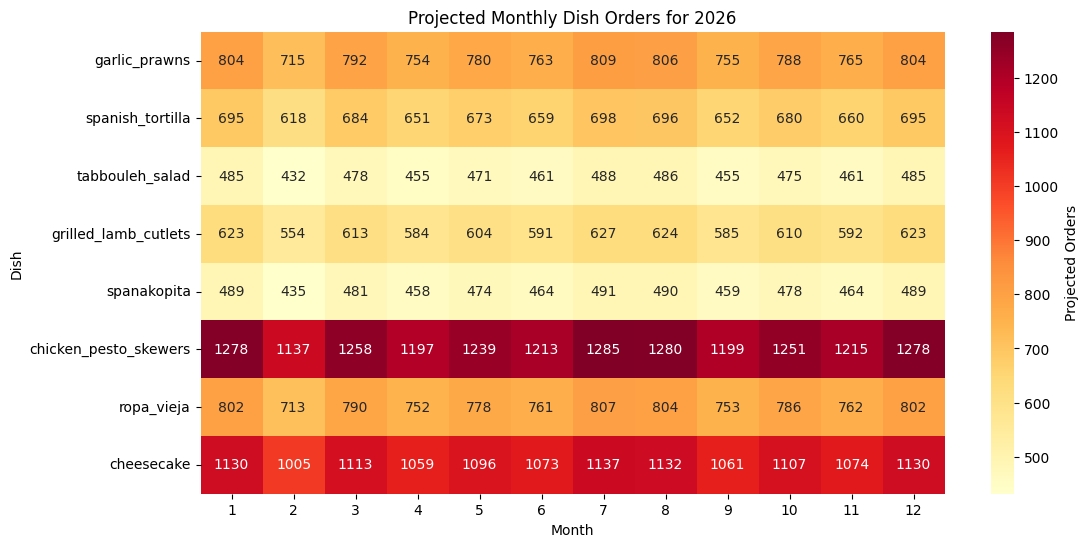

In [ ]:
# --- Prepare data for heatmap ---

heatmap_data = monthly_dishes_2026.set_index('month')[dish_columns]

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data.T,            # transpose to have dishes on y-axis
    annot=True,                # show numbers
    fmt=".0f",                 # integer formatting
    cmap="YlOrRd",             # color map
    cbar_kws={'label': 'Projected Orders'}  # colorbar label
)
plt.title("Projected Monthly Dish Orders for 2026")
plt.xlabel("Month")
plt.ylabel("Dish")
plt.yticks(rotation=0)        # keep dish names horizontal
plt.show()

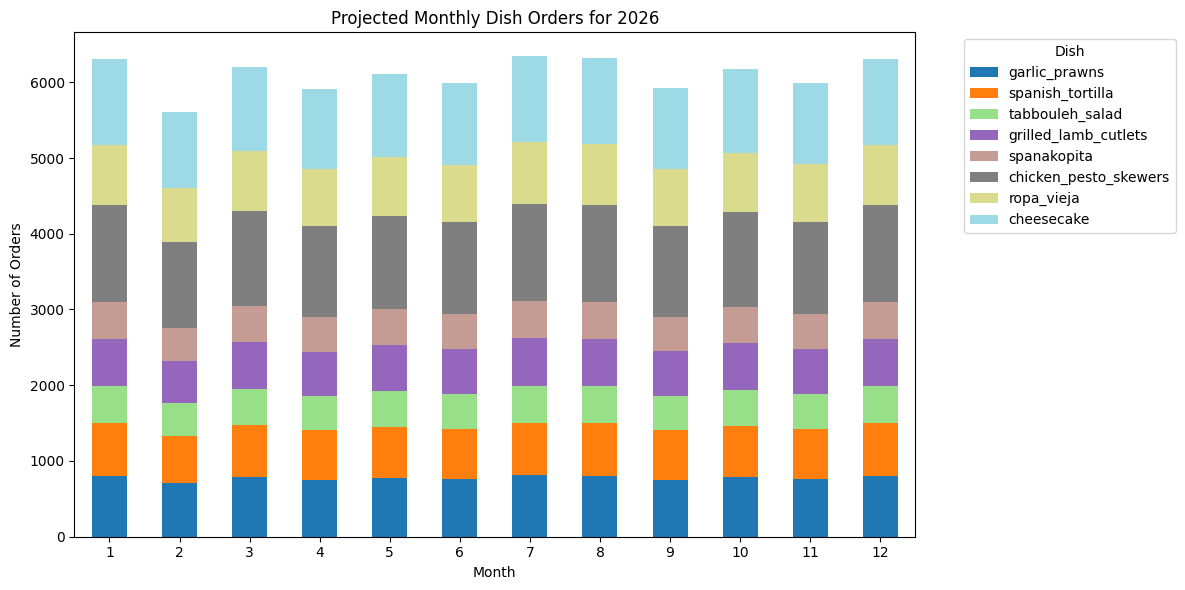

In [32]:
# --- Stacked Bar Chart of Projected Dish Orders per Month ---

# Prepare monthly aggregation
monthly_dishes_2026 = df_dishes_2026.groupby(df_dishes_2026['date'].dt.month)[dish_columns].sum()

# Plot
monthly_dishes_2026.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12,6),
    colormap='tab20'
)

plt.title("Projected Monthly Dish Orders for 2026")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.legend(title="Dish", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()